# ETTh1 exploratory data analysis

This notebook is a guided first look at the dataset used by both DLinear and PatchTST. The exploratory steps are written directly in the notebook so that you can see how the CSV is loaded, checked, split, summarized, and visualized.

**How to use it:** select the project `.venv` Python kernel, then choose **Run → Run All Cells**. Read the short notes above each result and change plot ranges or variables freely.

## 1. Read the CSV and create the benchmark partitions

We read the file with pandas, parse `date` as a timestamp, and use it as the time-series index. The reconstruction scripts use a stricter tested pipeline, but the equivalent exploratory steps remain visible here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 4), "axes.titlesize": 12})

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ETTh1.csv"
raw = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date")

# Fixed boundaries used by the DLinear and PatchTST ETTh1 benchmark.
TRAIN_ROWS = 12 * 30 * 24
VALIDATION_ROWS = 4 * 30 * 24
TEST_ROWS = 4 * 30 * 24
BENCHMARK_ROWS = TRAIN_ROWS + VALIDATION_ROWS + TEST_ROWS
FEATURE_COLUMNS = list(raw.columns)

benchmark = raw.iloc[:BENCHMARK_ROWS].copy()
train = benchmark.iloc[:TRAIN_ROWS]
validation = benchmark.iloc[TRAIN_ROWS : TRAIN_ROWS + VALIDATION_ROWS]
test = benchmark.iloc[TRAIN_ROWS + VALIDATION_ROWS :]
splits = {"train": train, "validation": validation, "test": test}

print(f"Loaded {len(raw):,} rows from {raw.index.min()} to {raw.index.max()}")

Loaded 17,420 rows from 2016-07-01 00:00:00 to 2018-06-26 19:00:00


## 2. Shape, columns, and first observations

`OT` is the transformer oil temperature. The other six variables describe different load measurements.

In [2]:
overview = pd.DataFrame(
    {
        "value": [
            len(raw),
            len(raw.columns),
            raw.index.min(),
            raw.index.max(),
            raw.index.inferred_freq,
            int(raw.isna().sum().sum()),
            int(raw.index.duplicated().sum()),
        ]
    },
    index=[
        "Rows",
        "Variables",
        "First timestamp",
        "Last timestamp",
        "Inferred frequency",
        "Missing values",
        "Duplicate timestamps",
    ],
)
display(overview)
display(raw.head())

,value
Rows,17420
Variables,7
First timestamp,2016-07-01 00:00:00
Last timestamp,2018-06-26 19:00:00
Inferred frequency,h
Missing values,0
Duplicate timestamps,0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


## 3. Numerical summary

Compare each variable's center, spread, and range. Large differences in scale are why the models use training-fitted standardization.

In [3]:
display(raw.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
HUFL,17420.0,7.375,7.068,-22.706,5.827,8.774,11.788,23.644
HULL,17420.0,2.242,2.042,-4.756,0.737,2.210,3.684,10.114
MUFL,17420.0,4.300,6.827,-25.088,3.296,5.970,8.635,17.341
MULL,17420.0,0.882,1.809,-5.934,-0.284,0.959,2.203,7.747
LUFL,17420.0,3.066,1.165,-1.188,2.315,2.833,3.625,8.498
LULL,17420.0,0.857,0.600,-1.371,0.670,0.975,1.218,3.046
OT,17420.0,13.325,8.567,-4.080,6.964,11.396,18.079,46.007


## 4. The seven time series

These full-resolution plots reveal long trends, seasonal movement, sudden changes, and differing variable scales.

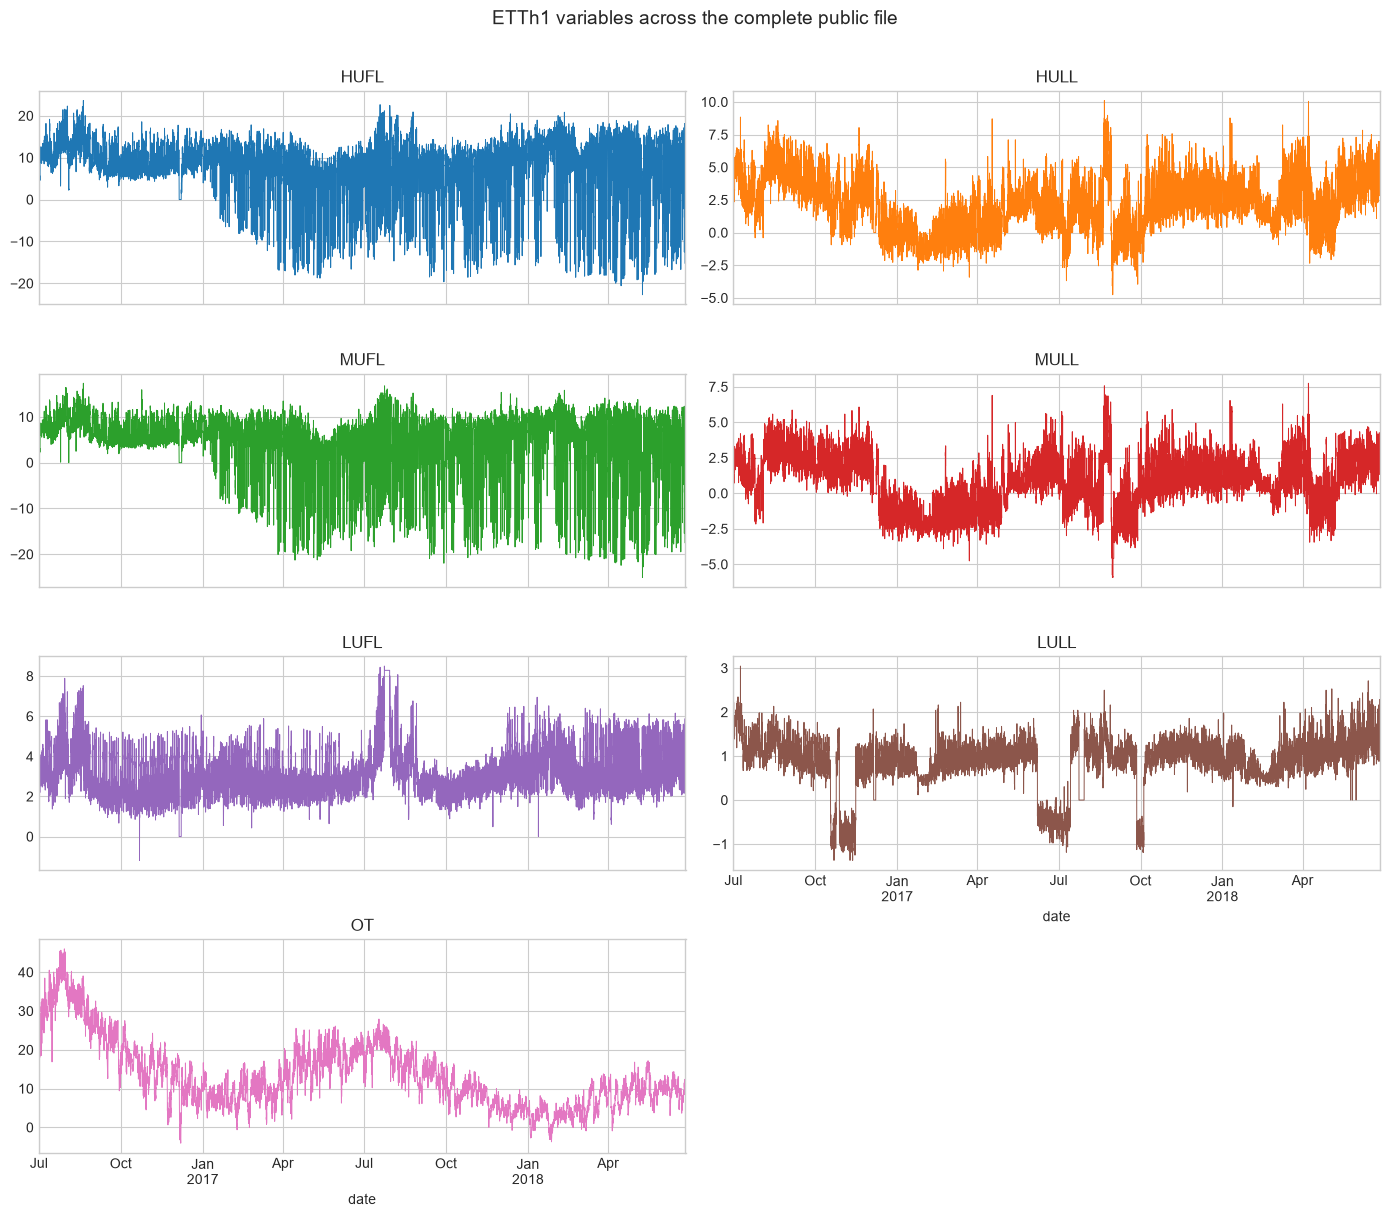

In [4]:
axes = raw.plot(
    subplots=True,
    layout=(4, 2),
    figsize=(14, 12),
    sharex=True,
    legend=False,
    linewidth=0.7,
    title=list(raw.columns),
)
plt.suptitle("ETTh1 variables across the complete public file", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Official benchmark boundaries

The papers use the first 12 months for training, followed by 4 months for validation and 4 months for testing. The remaining public observations are not part of this standard benchmark.

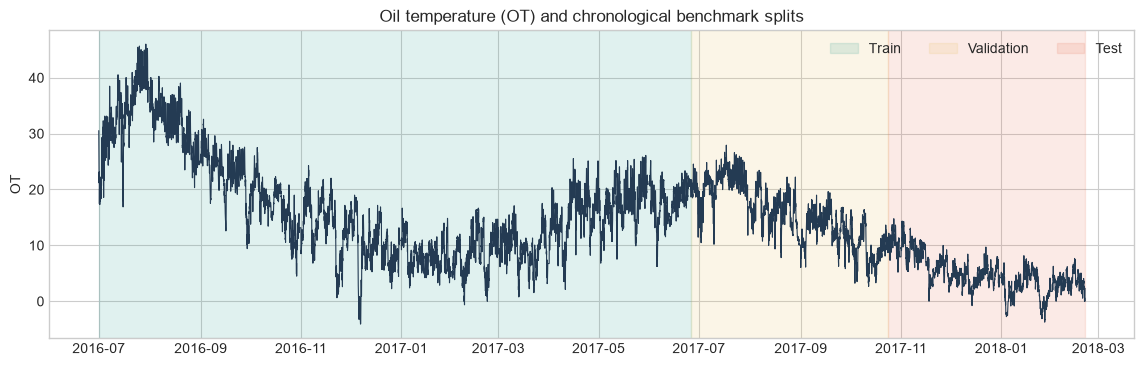

,rows,start,end,OT mean,OT std
train,8640,2016-07-01 00:00:00,2017-06-25 23:00:00,17.128262,9.177022
validation,2880,2017-06-26 00:00:00,2017-10-23 23:00:00,15.577956,4.974853
test,2880,2017-10-24 00:00:00,2018-02-20 23:00:00,4.84991,3.148788


In [5]:
train_end = benchmark.index[TRAIN_ROWS]
validation_end = benchmark.index[TRAIN_ROWS + VALIDATION_ROWS]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(benchmark.index, benchmark["OT"], linewidth=0.8, color="#243b53")
ax.axvspan(benchmark.index[0], train_end, alpha=0.14, color="#2a9d8f", label="Train")
ax.axvspan(train_end, validation_end, alpha=0.16, color="#e9c46a", label="Validation")
ax.axvspan(validation_end, benchmark.index[-1], alpha=0.14, color="#e76f51", label="Test")
ax.set(title="Oil temperature (OT) and chronological benchmark splits", ylabel="OT")
ax.legend(ncols=3)
plt.show()

split_summary = pd.DataFrame(
    {
        name: {
            "rows": len(part),
            "start": part.index.min(),
            "end": part.index.max(),
            "OT mean": part["OT"].mean(),
            "OT std": part["OT"].std(),
        }
        for name, part in splits.items()
    }
).T
display(split_summary)

## 6. Distributions and relationships

Histograms show whether variables are symmetric, skewed, or multimodal. The correlation matrix shows linear relationships, but correlation does not imply causation.

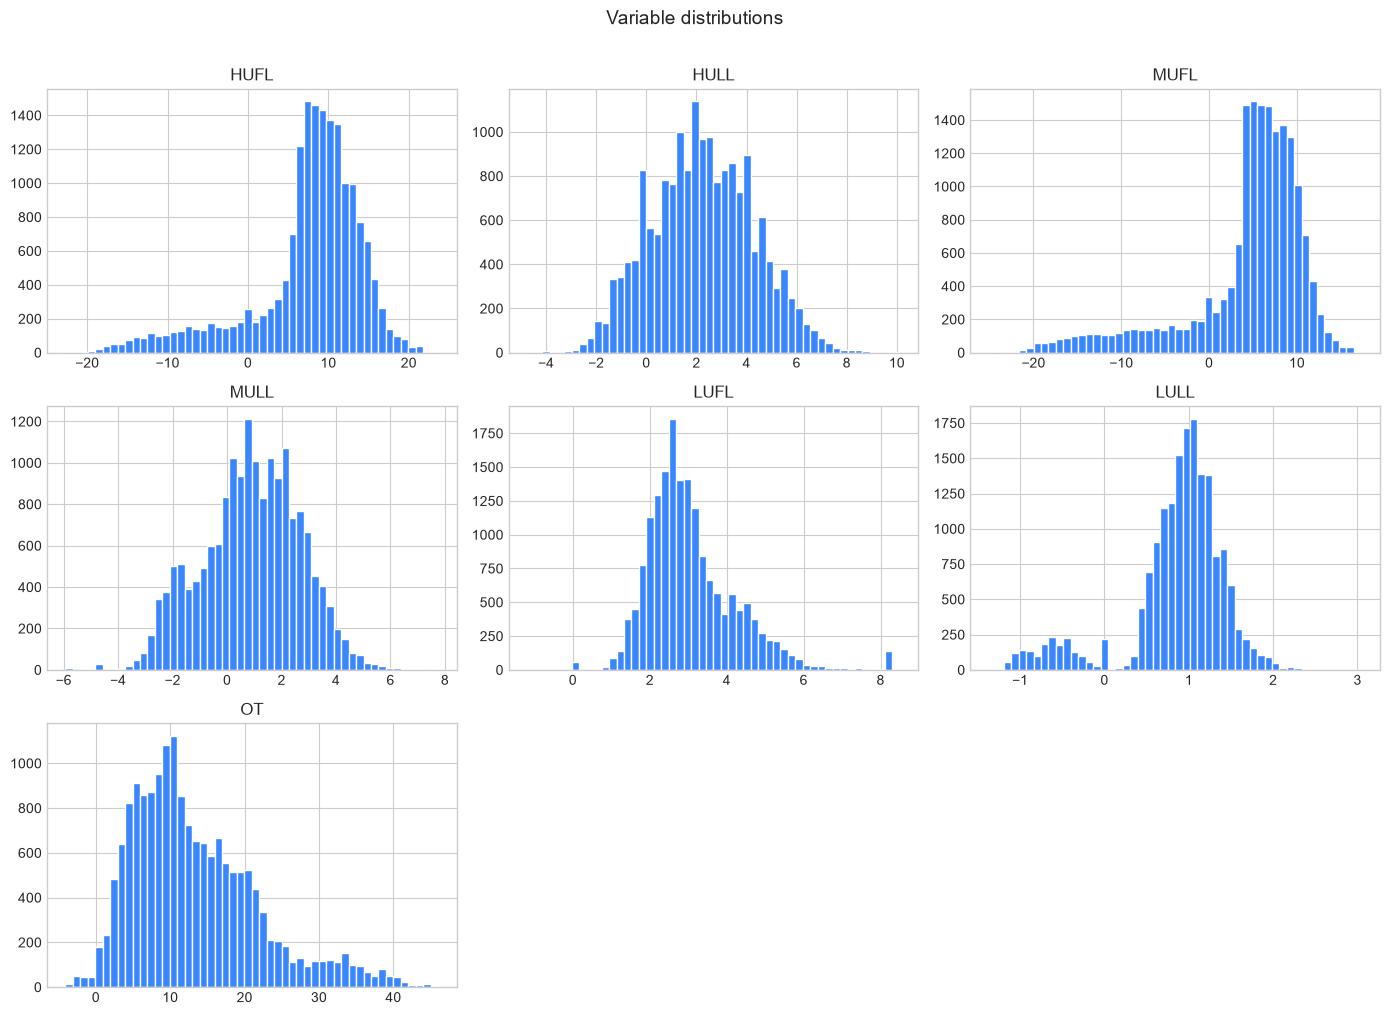

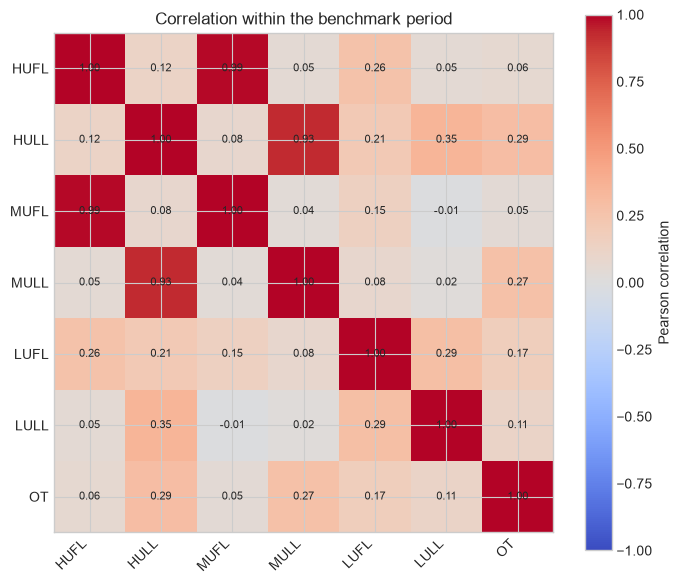

In [6]:
raw.hist(bins=50, figsize=(14, 10), color="#3a86ff", edgecolor="white")
plt.suptitle("Variable distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

correlation = benchmark.corr()
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(FEATURE_COLUMNS)), FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLUMNS)), FEATURE_COLUMNS)
for row in range(len(FEATURE_COLUMNS)):
    for column in range(len(FEATURE_COLUMNS)):
        ax.text(column, row, f"{correlation.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Correlation within the benchmark period")
plt.tight_layout()
plt.show()

## 7. Hourly and weekly seasonality

Averaging oil temperature by hour and weekday gives a simple view of recurring calendar patterns.

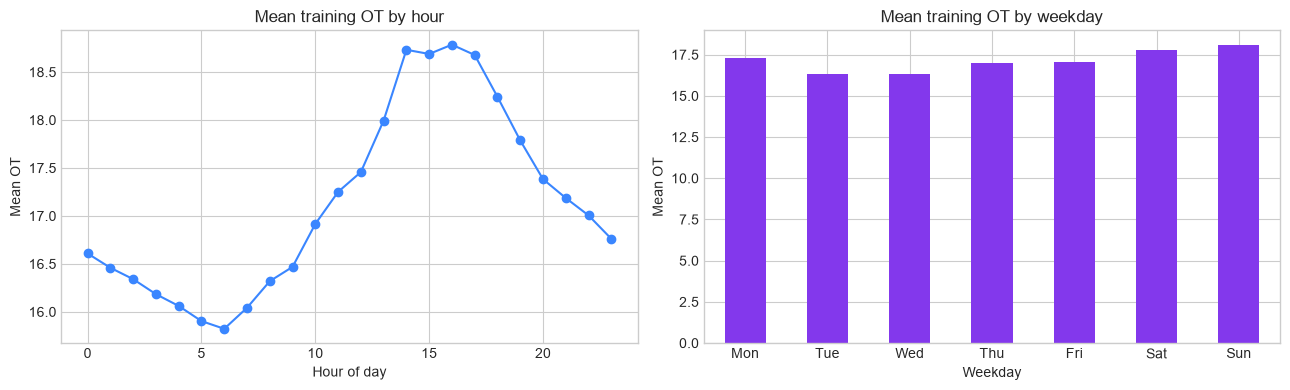

In [7]:
hourly_ot = train["OT"].groupby(train.index.hour).mean()
weekday_ot = train["OT"].groupby(train.index.dayofweek).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
hourly_ot.plot(ax=axes[0], marker="o", color="#3a86ff")
axes[0].set(title="Mean training OT by hour", xlabel="Hour of day", ylabel="Mean OT")
weekday_ot.plot(ax=axes[1], kind="bar", color="#8338ec")
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
axes[1].set(title="Mean training OT by weekday", xlabel="Weekday", ylabel="Mean OT")
plt.tight_layout()
plt.show()

## 8. Do all variables behave similarly across the three splits?

A chronological split can create a difficult but realistic distribution shift. The table reports each variable's original mean and standard deviation in each split. The plots then express each split relative to the training distribution: a mean shift of `1` means one training standard deviation above the training mean, while a standard-deviation ratio of `1` means equal variability.

This comparison is descriptive only. We still fit every scaler and model using training data alone.

train        validation          test       
        mean    std       mean    std   mean    std
HUFL   7.938  5.813      6.483  7.279  8.121  7.657
HULL   2.021  2.090      1.525  2.224  2.971  1.230
MUFL   5.080  5.519      3.434  7.234  4.766  7.429
MULL   0.746  1.926      0.370  2.011  1.457  1.014
LUFL   2.782  1.024      3.379  1.580  3.288  0.914
LULL   0.788  0.630      0.670  0.784  0.969  0.301
OT    17.128  9.177     15.578  4.975  4.850  3.149

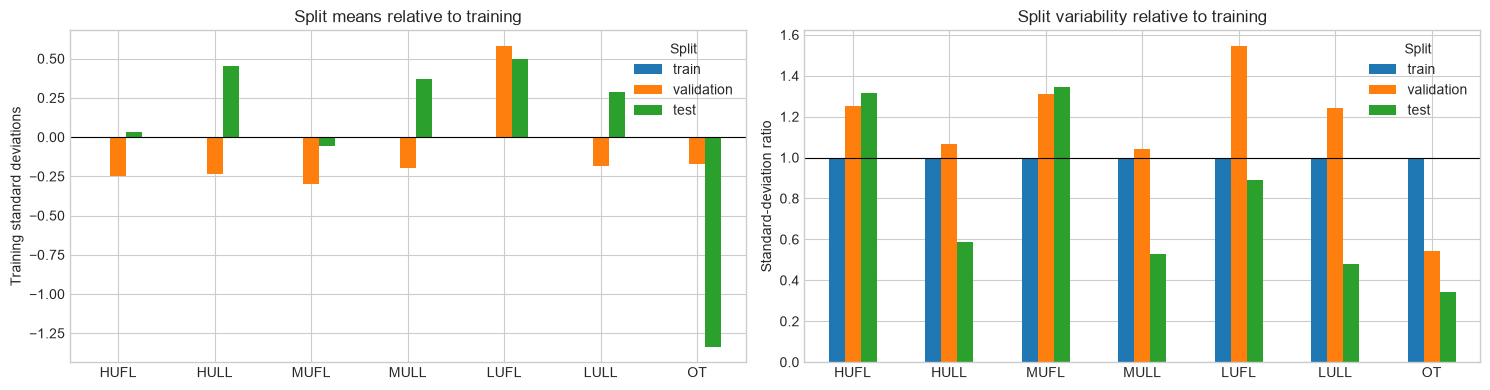

In [8]:
split_statistics = pd.concat(
    {name: part[FEATURE_COLUMNS].agg(["mean", "std"]).T for name, part in splits.items()},
    axis=1,
)
display(split_statistics.round(3))

train_mean = train[FEATURE_COLUMNS].mean()
train_std = train[FEATURE_COLUMNS].std()

standardized_mean_shift = pd.DataFrame(
    {
        name: (part[FEATURE_COLUMNS].mean() - train_mean) / train_std
        for name, part in splits.items()
    }
).T
standard_deviation_ratio = pd.DataFrame(
    {name: part[FEATURE_COLUMNS].std() / train_std for name, part in splits.items()}
).T

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
standardized_mean_shift.T.plot(kind="bar", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Split means relative to training", ylabel="Training standard deviations")

standard_deviation_ratio.T.plot(kind="bar", ax=axes[1])
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set(title="Split variability relative to training", ylabel="Standard-deviation ratio")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Split")
plt.tight_layout()
plt.show()

## 9. Autocorrelation at meaningful hourly lags

Autocorrelation compares each variable with its own earlier values. For hourly ETTh1 data, lag `1` is one hour, lag `24` is one day, lag `168` is one week, and lag `336` is two weeks (our planned input length).

Only the training split is used here. A high value at lag 24, for example, means that observations at the same hour on consecutive days tend to move together; it does not prove a causal relationship.

,1,24,168,336
HUFL,0.925,0.800,0.699,0.660
HULL,0.932,0.846,0.740,0.657
MUFL,0.928,0.807,0.717,0.683
MULL,0.934,0.868,0.784,0.715
LUFL,0.850,0.340,0.374,0.281
LULL,0.965,0.822,0.575,0.387
OT,0.993,0.929,0.853,0.839


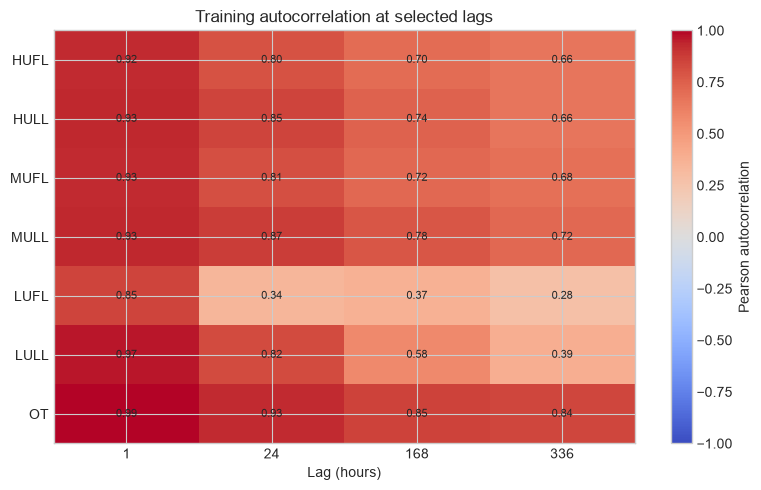

In [9]:
important_lags = [1, 24, 168, 336]
autocorrelation = pd.DataFrame(
    {
        lag: train[FEATURE_COLUMNS].corrwith(train[FEATURE_COLUMNS].shift(lag))
        for lag in important_lags
    }
)
display(autocorrelation.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(autocorrelation, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(important_lags)), labels=important_lags)
ax.set_yticks(range(len(FEATURE_COLUMNS)), labels=FEATURE_COLUMNS)
ax.set(xlabel="Lag (hours)", title="Training autocorrelation at selected lags")
for row in range(len(FEATURE_COLUMNS)):
    for column in range(len(important_lags)):
        ax.text(
            column,
            row,
            f"{autocorrelation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
fig.colorbar(image, ax=ax, label="Pearson autocorrelation")
plt.tight_layout()
plt.show()

## 10. Do earlier load values relate to later oil temperature?

The earlier correlation matrix compared different channels at the **same hour**. Here, a positive lag `k` compares `load at time t - k` with `OT at time t`. It therefore asks whether an earlier load measurement may contain information about later oil temperature. This is different from OT autocorrelation, which compares past OT with later OT.

The analysis uses only training data and remains exploratory. Correlation measures linear association, can be influenced by shared trends or seasonality, and does not establish causation or guarantee that a forecasting model will improve.

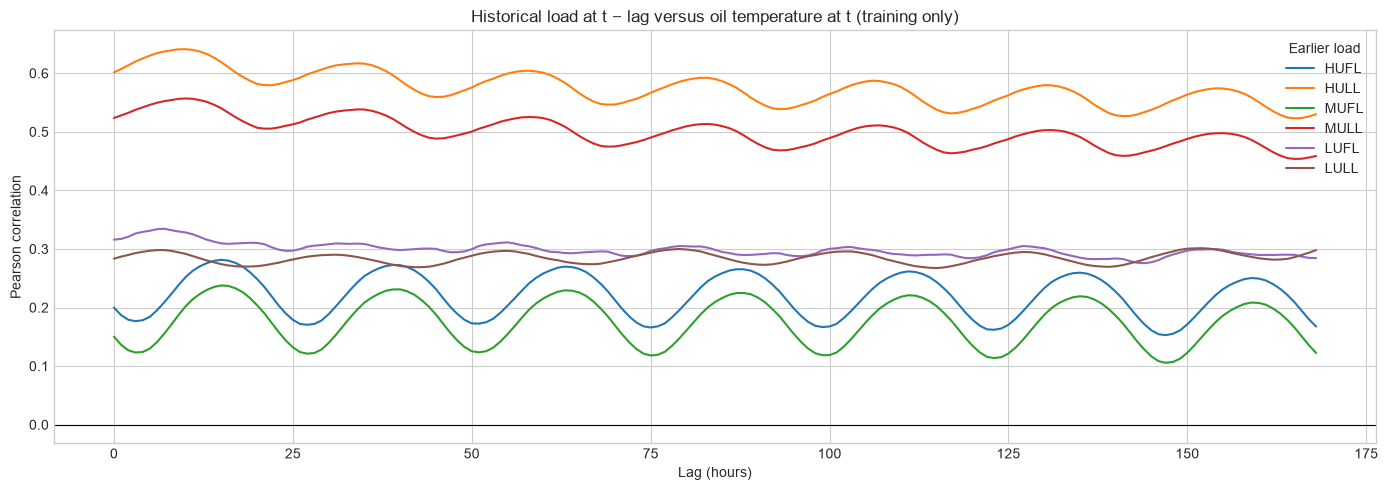

,strongest_absolute_lag_hours,correlation_at_that_lag
HUFL,15,0.281
HULL,10,0.641
MUFL,15,0.238
MULL,10,0.557
LUFL,7,0.335
LULL,152,0.301


In [10]:
load_columns = [column for column in FEATURE_COLUMNS if column != "OT"]
candidate_lags = range(0, 169)

lagged_load_to_ot = pd.DataFrame(
    {
        column: [train[column].shift(lag).corr(train["OT"]) for lag in candidate_lags]
        for column in load_columns
    },
    index=candidate_lags,
)
lagged_load_to_ot.index.name = "lag_hours"

fig, ax = plt.subplots(figsize=(14, 5))
lagged_load_to_ot.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Historical load at t − lag versus oil temperature at t (training only)",
    xlabel="Lag (hours)",
    ylabel="Pearson correlation",
)
ax.legend(title="Earlier load")
plt.tight_layout()
plt.show()

strongest_lagged_relationship = pd.DataFrame(
    {
        "strongest_absolute_lag_hours": lagged_load_to_ot.abs().idxmax(),
        "correlation_at_that_lag": {
            column: lagged_load_to_ot.loc[lagged_load_to_ot[column].abs().idxmax(), column]
            for column in load_columns
        },
    }
)
display(strongest_lagged_relationship.round(3))

## 11. What one forecasting example looks like

The first validation example uses the previous 336 hours as input and asks the model to forecast the next 96 hours. Notice that the target starts only after the input ends.

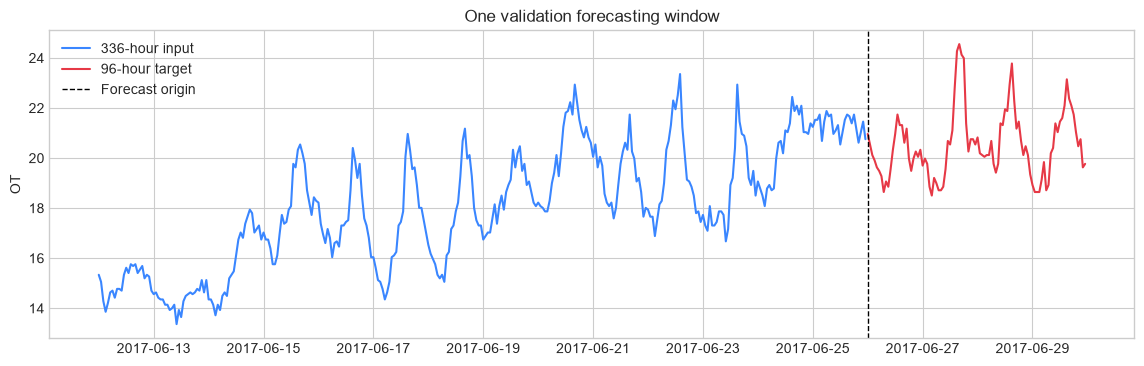

     train: 8,209 windows | input (336, 7) -> target (96, 7)
validation: 2,785 windows | input (336, 7) -> target (96, 7)
      test: 2,785 windows | input (336, 7) -> target (96, 7)


In [11]:
input_length = 336
prediction_length = 96
origin = TRAIN_ROWS  # First validation target begins after all training rows.
input_slice = benchmark.iloc[origin - input_length : origin]
target_slice = benchmark.iloc[origin : origin + prediction_length]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(input_slice.index, input_slice["OT"], label="336-hour input", color="#3a86ff")
ax.plot(target_slice.index, target_slice["OT"], label="96-hour target", color="#e63946")
ax.axvline(target_slice.index[0], color="black", linestyle="--", linewidth=1, label="Forecast origin")
ax.set(title="One validation forecasting window", ylabel="OT")
ax.legend()
plt.show()

window_counts = {
    "train": TRAIN_ROWS - input_length - prediction_length + 1,
    "validation": VALIDATION_ROWS - prediction_length + 1,
    "test": TEST_ROWS - prediction_length + 1,
}
input_shape = (input_length, len(FEATURE_COLUMNS))
target_shape = (prediction_length, len(FEATURE_COLUMNS))

for name, count in window_counts.items():
    print(f"{name:>10}: {count:,} windows | input {input_shape} -> target {target_shape}")

## Questions to think about

1. Which variables appear most strongly related?
2. Do the validation and test periods look statistically similar to training?
3. Which repeating patterns might help a forecasting model?
4. Are there abrupt changes or unusual regions that may make forecasting difficult?
5. After changing `prediction_length` to 192 or 336, how does the forecasting task feel different?

Your observations here can later guide the meaningful improvement we design.